In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [13]:
df = pd.read_csv("sensor_raw.csv")
print(df.head())
print("=" * 40)
print(f"Rows: {df.size}")
print(f"Cols: {df.columns}")
print(f"Missing: {(df.isnull().sum())}")





   Class  DriverID  TaskID  Hour  Minute  Second     GyroX     GyroY  \
0      3  Driver-1       1    15      39      39 -0.496183  2.511450   
1      3  Driver-1       1    15      39      40 -1.519084  2.832061   
2      3  Driver-1       1    15      39      41  0.679389  3.206107   
3      3  Driver-1       1    15      39      42  0.053435  9.244275   
4      3  Driver-1       1    15      39      42 -0.664122  8.030534   

      GyroZ      AccX      AccY      AccZ  
0  0.702290  0.226807 -0.132324 -1.010498  
1 -1.244275  0.331299 -0.145752 -0.998291  
2 -0.229008  0.431396 -0.209717 -1.004150  
3  2.893130  0.370117 -0.062012 -0.901123  
4  0.961832  0.364990 -0.132324 -1.001221  
Rows: 13368
Cols: Index(['Class', 'DriverID', 'TaskID', 'Hour', 'Minute', 'Second', 'GyroX',
       'GyroY', 'GyroZ', 'AccX', 'AccY', 'AccZ'],
      dtype='str')
Missing: Class       0
DriverID    0
TaskID      0
Hour        0
Minute      0
Second      0
GyroX       0
GyroY       0
GyroZ       0
AccX  

In [25]:
samples_per_second = df.groupby(['Hour', 'Minute', 'Second']).size()
print("Samples per second distribution:")
print(samples_per_second.value_counts())
estimated_hz = samples_per_second.mode()[0]
print(f"\nEstimated Sampling Rate: {estimated_hz} Hz")

Samples per second distribution:
1    571
2    193
3     34
4      7
5      3
6      2
Name: count, dtype: int64

Estimated Sampling Rate: 1 Hz


In [42]:
# Number of driving events
df.groupby(['Class']).size()

Class
1    252
2    288
3    350
4    224
dtype: int64

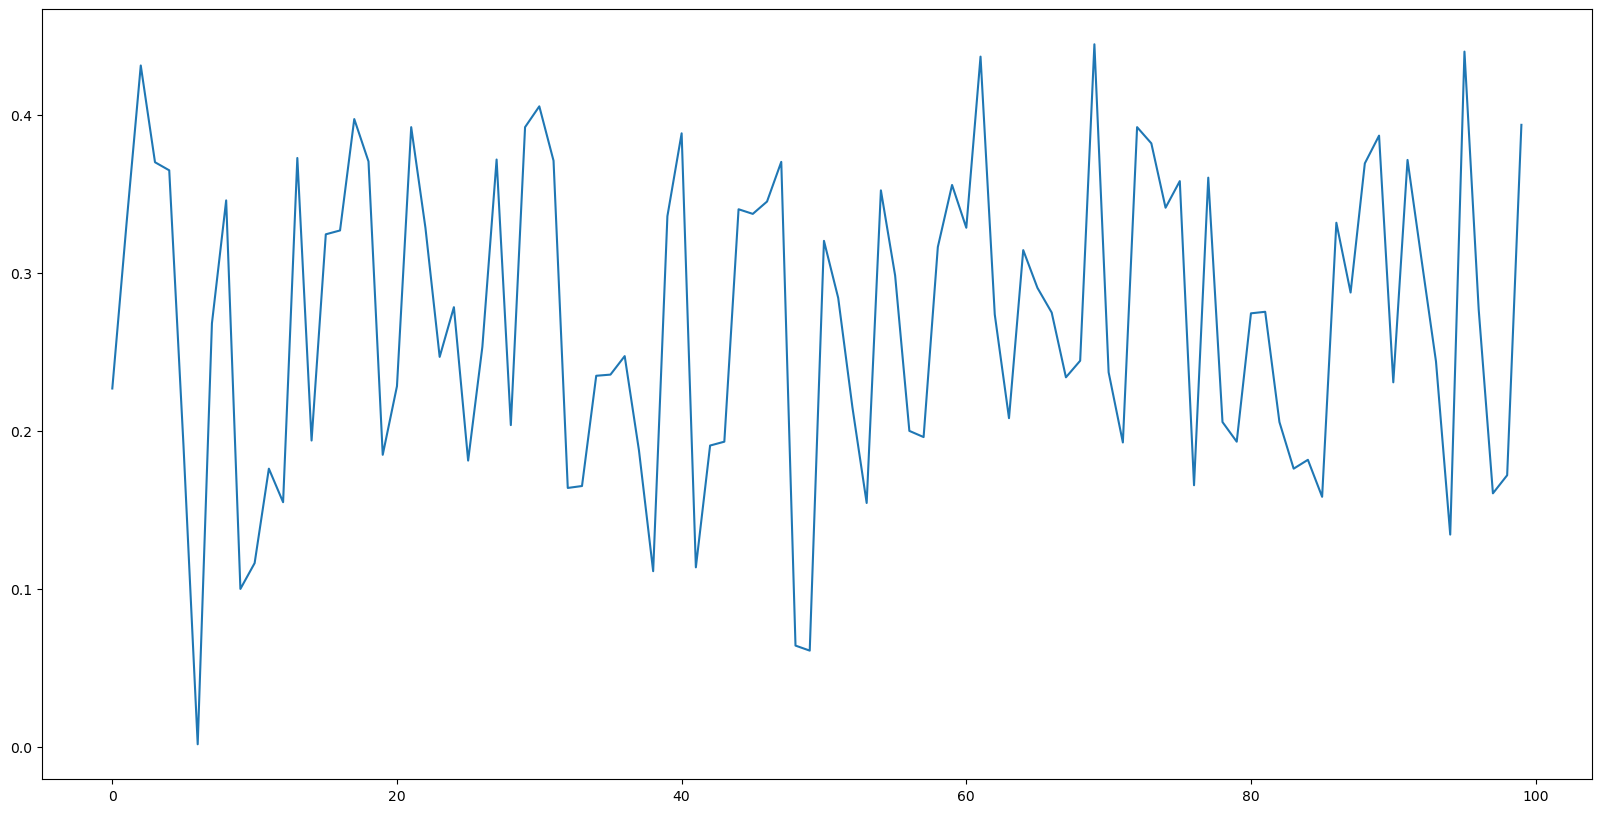

In [34]:
plt.figure(figsize=(20,10))
plt.plot(df['AccX'].iloc[:100])